In [9]:
import sys
sys.path.append("..")

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from src.config import TEST_DIR
from src.inference import (
    load_trained_model,
    load_label_map,
    predict_image,
    predict_top_k,
)

In [10]:
model = load_trained_model()
label_map = load_label_map()

print("Model and label map loaded successfully.")

Model and label map loaded successfully.


In [11]:
test_files = sorted(list(Path(TEST_DIR).glob("*.jpg")))
print("Total test files:", len(test_files))
print([p.name for p in test_files[:10]])

Total test files: 28
['A_test.jpg', 'B_test.jpg', 'C_test.jpg', 'D_test.jpg', 'E_test.jpg', 'F_test.jpg', 'G_test.jpg', 'H_test.jpg', 'I_test.jpg', 'J_test.jpg']


In [12]:
sample_path = str(test_files[0])

result = predict_image(model, sample_path, label_map)
top3 = predict_top_k(model, sample_path, label_map, k=3)

print("Image:", Path(sample_path).name)
print("Prediction:", result)
print("Top-3:", top3)

Image: A_test.jpg
Prediction: {'label': 'A', 'confidence': 0.9999635219573975}
Top-3: [('A', 0.9999635219573975), ('S', 3.621603173087351e-05), ('E', 1.1771267338644975e-07)]


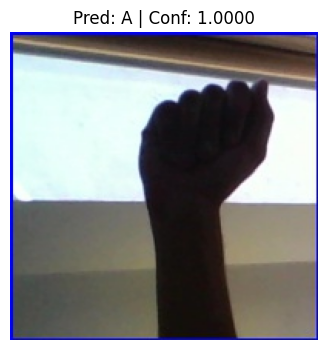

In [13]:
img = Image.open(sample_path)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Pred: {result['label']} | Conf: {result['confidence']:.4f}")
plt.axis("off")
plt.show()

In [14]:
results = []

for img_path in test_files:
    pred = predict_image(model, str(img_path), label_map)
    results.append({
        "filename": img_path.name,
        "pred_label": pred["label"],
        "confidence": pred["confidence"]
    })

results[:5]

[{'filename': 'A_test.jpg',
  'pred_label': 'A',
  'confidence': 0.9999635219573975},
 {'filename': 'B_test.jpg', 'pred_label': 'B', 'confidence': 1.0},
 {'filename': 'C_test.jpg',
  'pred_label': 'C',
  'confidence': 0.9999988079071045},
 {'filename': 'D_test.jpg',
  'pred_label': 'D',
  'confidence': 0.999821126461029},
 {'filename': 'E_test.jpg',
  'pred_label': 'E',
  'confidence': 0.9999388456344604}]

In [15]:
import pandas as pd
results_df = pd.DataFrame(results)
results_df

,filename,pred_label,confidence
0,A_test.jpg,A,0.999964
1,B_test.jpg,B,1.000000
2,C_test.jpg,C,0.999999
3,D_test.jpg,D,0.999821
4,E_test.jpg,E,0.999939
5,F_test.jpg,F,1.000000
6,G_test.jpg,G,0.999998
7,H_test.jpg,H,0.999951
8,I_test.jpg,I,0.996896
9,J_test.jpg,J,0.999871


In [16]:
results_df["true_label"] = results_df["filename"].str.replace("_test.jpg", "", regex=False)
results_df["correct"] = results_df["true_label"] == results_df["pred_label"]
results_df

,filename,pred_label,confidence,true_label,correct
0,A_test.jpg,A,0.999964,A,True
1,B_test.jpg,B,1.000000,B,True
2,C_test.jpg,C,0.999999,C,True
3,D_test.jpg,D,0.999821,D,True
4,E_test.jpg,E,0.999939,E,True
5,F_test.jpg,F,1.000000,F,True
6,G_test.jpg,G,0.999998,G,True
7,H_test.jpg,H,0.999951,H,True
8,I_test.jpg,I,0.996896,I,True
9,J_test.jpg,J,0.999871,J,True
